### Excercise 1

The Probabilistic PCA model is a linear generative model with isotropic noise:
\begin{align*}
x &= Wz + \mu + \epsilon, & z &\sim \mathcal{N} (0,I_q), & \epsilon & \sim \mathcal{N}(0,\sigma^2 I_d)
\end{align*}
so that observations are generated from latent variables $z$ and a noise term $\epsilon$.

1. Show that the marginal distribution of $x$ is Gaussian with covariance $WW^T + \sigma^2 I_d$.

**Solution:**

Since $x = Wz + \mu + \epsilon$, where $z$ and $\epsilon$ are independent, zero-mean Gaussian variables with respective covariances $I_q$ and $\sigma^2 I_d$, the moment generating function of $x$ is given by:
\begin{align*}
M_x(t) &= \mathbb{E}[\exp\left({t^T x}\right)]\\
&= \mathbb{E}[\exp\left({t^T (Wz + \mu + \epsilon)}\right)] \\
&= \exp\left({t^T \mu}\right) \mathbb{E}[\exp\left({t^T Wz}\right)] \mathbb{E}[\exp\left({t^T \epsilon}\right)] \\
&= \exp\left({t^T \mu}\right) \mathbb{E}[\exp\left({(W^Tt)^T z}\right)] \mathbb{E}[\exp\left({t^T \epsilon}\right)] \\
&= \exp\left({t^T \mu}\right) \exp\left({\frac{1}{2} (W^T t)^T I_q (W^T t)}\right) \exp\left({\frac{1}{2} t^T (\sigma^2 I_d) t}\right) \\
&= \exp\left({t^T \mu + \frac{1}{2} t^T (WW^T + \sigma^2 I_d) t}\right)
\end{align*}
This is the moment generating function of a Gaussian distribution with mean $\mu$ and covariance $WW^T + \sigma^2 I_d$. Therefore, the marginal distribution of $x$ is Gaussian with covariance $WW^T + \sigma^2 I_d$.

2. Discuss what happens with the ML solutions for $W$ when $\sigma^2 \to 0$.
3. Explain why in this limit the estimated directions coincide with those of classic PCA.

**Solution:**

Remember that the ML solution for $W$ is given by:
\begin{align*}
W_{ML} &= U_q (\Lambda_d - \sigma^2 I_d)^{1/2} R, & R^T R = I_d
\end{align*}
where $U_q$ are the first $q$ eigenvectors of the data covariance matrix, $\Lambda_d$ is a diagonal matrix with the first $d$ eigenvalues of the data covariance matrix, and $R$ is an arbitrary rotation matrix.\\
As $\sigma^2 \to 0$, the term $(\Lambda_d - \sigma^2 I_d)$ approaches $\Lambda_d$. Therefore, the ML solution for $W$ approaches:
\begin{align*}
W_{ML} &\to U_q \Lambda_d^{1/2} R
\end{align*}
Note then, $W_{ML} W_{ML}^T = U_q \Lambda_d U_q^T$, which is the rank-$q$ approximation of the data covariance matrix obtained from PCA. This means that as the noise variance $\sigma^2$ approaches zero, the probabilistic PCA model converges to the standard PCA model, where the data is assumed to lie exactly in a $q$-dimensional subspace without any noise.
The directions estimated by probabilistic PCA in this limit coincide with those of classic PCA because both methods are effectively capturing the same underlying structure in the data, which is defined by the leading eigenvectors of the data covariance matrix. All of the variance in the data is explained by the principal components, and there is no additional noise to account for.

### Excercise 2
1. Implement a Variational Autoencoder (VAE) under the assumption that all the distributions involved are Gaussian:
- Prior: $p(z) = \mathcal{N}(z;0,I)$.
- Encoder: $q_\phi(z|x) = \mathcal{N}(z;\mu_\phi(x),\operatorname{diag}(\sigma^2_\phi(x)))$.
- Decoder: $p_\theta(x|z) = \mathcal{N}(x;\mu_\theta(z),\frac{1}{2}I_d)$.
- Train the model by maximizing the ELBO.


In [1]:
# Imports for VAE MNIST example
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#
# Encoder q(z|x)
#
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # mean of latent distribution
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        # log-variance of latent distribution
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)
    def forward(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var

In [3]:
# Reparameterization trick
# z = mu + sigma * eps
#
def reparameterize(mu, log_var):
    # standard deviation
    std = torch.exp(0.5 * log_var)
    # sample epsilon ~ N(0, Ι)
    eps = torch.randn_like(std)
    # reparameterized sample
    return mu + eps * std

In [4]:
# Decoder p(x|z)
class Decoder(nn.Module):
    def __init__(self, z_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(z_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
    def forward(self, z):
        h = F.relu(self.fc1(z))
        # outputs in [0,1]
        x_recon = torch.sigmoid(self.fc_out(h))
        return x_recon

In [5]:
#
# Variational Autoencoder
#
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, z_dim)
        self.decoder = Decoder(z_dim, hidden_dim, input_dim)
    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var
    def estimate_px_monte_carlo(self, x, num_samples=100):
        """
        Estimate p(x) for a batch of data x using the Monte Carlo estimator:
        p(x) ≈ (1/K) sum_k p_theta(x|z_k) p(z_k) / q_phi(z_k|x)
        Args:
            x: input batch (tensor)
            num_samples: number of importance samples (K)
        Returns:
            px: estimated p(x) for each sample in the batch (tensor)
        """
        self.eval()
        with torch.no_grad():
            mu, log_var = self.encoder(x)
            mu = mu.unsqueeze(1).expand(-1, num_samples, -1)
            log_var = log_var.unsqueeze(1).expand(-1, num_samples, -1)
            x_exp = x.unsqueeze(1).expand(-1, num_samples, -1)
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            z = mu + eps * std
            x_recon = self.decoder(z)
            # log p(x|z) for Gaussian with fixed variance
            log_px_z = -((x_exp - x_recon) ** 2).sum(dim=-1)
            # log p(z) for standard normal
            log_pz = -0.5 * (z ** 2).sum(dim=-1)
            # log q(z|x) for diagonal Gaussian
            log_qz_x = -0.5 * (((z - mu) ** 2) / (std ** 2) + 2 * torch.log(std)).sum(dim=-1)
            # Importance weights
            log_weight = log_px_z + log_pz - log_qz_x
            # Monte Carlo estimator: p(x) ≈ (1/K) sum_k exp(log_weight_k)
            px = torch.exp(torch.logsumexp(log_weight, dim=1) - torch.log(torch.tensor(num_samples, dtype=log_weight.dtype, device=log_weight.device)))
        return px


In [6]:
# Loss function
# ELBO = Reconstruction loss + KL divergence
#
def vae_loss(x, x_recon, mu, log_var):
    # Fixed variance sigma^2 = 0.5 (sigma = sqrt(2)/2)
    # For sigma^2=0.5, 2*sigma^2=1, so denominator is 1
    # Gaussian NLL (ignoring constant term) reduces to MSE sum
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")
    # KL divergence between q(z|x) and p(z)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss


In [7]:
# Hyperparameters
#
dim_input = 28 * 28 # Flattened MNIST image size
hidden_units = 128 # Hidden layer size
dim_z = 32 # Latent space dimension
batch_size = 256
epochs = 200
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# Setup
#
# Transform: convert to tensor and flatten to 784-dim vector
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
#
# Training loaders
#
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#
# Testing / reconstruction loaders
#
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [9]:
vae = VAE(dim_input, hidden_units, dim_z).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

In [10]:
# Training loop
#
for epoch in range(epochs):
    vae.train()
    train_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, log_var = vae(x)
        loss = vae_loss(x, x_recon, mu, log_var)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader.dataset):.4f}")


Epoch 1/200, Loss: 62.6403
Epoch 2/200, Loss: 43.6195
Epoch 3/200, Loss: 39.5397
Epoch 4/200, Loss: 37.1151
Epoch 5/200, Loss: 35.6050
Epoch 6/200, Loss: 34.7181
Epoch 7/200, Loss: 34.0883
Epoch 8/200, Loss: 33.5939
Epoch 9/200, Loss: 33.1987
Epoch 10/200, Loss: 32.8904
Epoch 11/200, Loss: 32.6485
Epoch 12/200, Loss: 32.4372
Epoch 13/200, Loss: 32.2499
Epoch 14/200, Loss: 32.1242
Epoch 15/200, Loss: 31.9605
Epoch 16/200, Loss: 31.8793
Epoch 17/200, Loss: 31.7743
Epoch 18/200, Loss: 31.6886
Epoch 19/200, Loss: 31.6168
Epoch 20/200, Loss: 31.5327
Epoch 21/200, Loss: 31.4695
Epoch 22/200, Loss: 31.3876
Epoch 23/200, Loss: 31.3434
Epoch 24/200, Loss: 31.2950
Epoch 25/200, Loss: 31.2592
Epoch 26/200, Loss: 31.2162
Epoch 27/200, Loss: 31.1649
Epoch 28/200, Loss: 31.1263
Epoch 29/200, Loss: 31.0824
Epoch 30/200, Loss: 31.0340
Epoch 31/200, Loss: 31.0213
Epoch 32/200, Loss: 30.9727
Epoch 33/200, Loss: 30.9391
Epoch 34/200, Loss: 30.8665
Epoch 35/200, Loss: 30.8672
Epoch 36/200, Loss: 30.8274
E

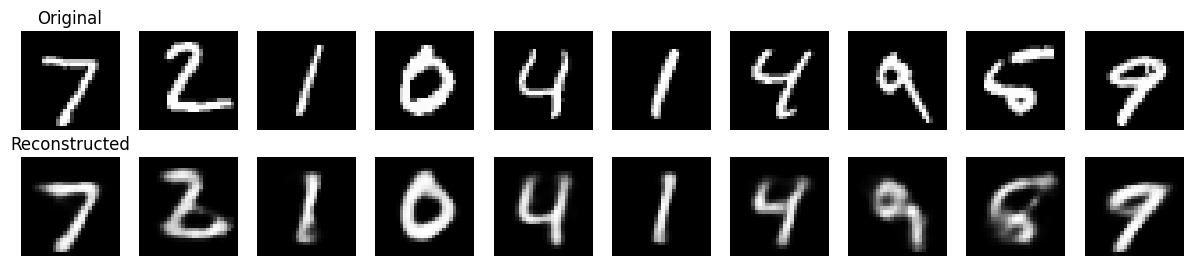

In [11]:
# Sample the first 10 images from the test dataset
vae.eval()
with torch.no_grad():
    for x, _ in test_loader:
        x = x[:10].to(device)  # Take the first 10 images
        x_recon, _, _ = vae(x)
        break

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    # Original images
    axes[0, i].imshow(x[i].cpu().view(28, 28), cmap="gray")
    axes[0, i].axis("off")
    # Reconstructed images
    axes[1, i].imshow(x_recon[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.show()

2. Starting from the definition
$$
p_\theta (x) = \int p_\theta(x|z)p(z)dz
$$
show that, by introducing the encoder $q_\phi(z|x)$, one obtains
$$
p_\theta (x) = \mathbb{E}_{z \sim q_\phi(z|x)} \left[ \frac{p_\theta(x|z)p(z)}{q_\phi(z|x)} \right].
$$
Conclude that a Monte Carlo estimate of $p_\theta(x)$ is given by
$$
\hat{p}_\theta(x) = \frac{1}{K} \sum_{k=1}^K \frac{p_\theta(x|z^{(k)})p(z^{(k)})}{q_\phi(z^{(k)}|x)}.
$$
where $z^{(k)} \sim q_\phi(z|x)$.

**Solution:**

Starting from the definition of the marginal likelihood:
\begin{align*}
p_\theta (x) &= \int p_\theta(x|z)p(z)dz
\end{align*}
We can introduce the encoder $q_\phi(z|x)$ by multiplying and dividing the integrand by $q_\phi(z|x)$:
\begin{align*}
p_\theta (x) &= \int p_\theta(x|z)p(z) \frac{q_\phi(z|x)}{q_\phi(z|x)} dz \\
&= \int q_\phi(z|x) \frac{p_\theta(x|z)p(z)}{q_\phi(z|x)} dz \\
&= \mathbb{E}_{z \sim q_\phi(z|x)} \left[ \frac{p_\theta(x|z)p(z)}{q_\phi(z|x)} \right]
\end{align*}
This shows that the marginal likelihood can be expressed as an expectation with respect to the encoder distribution. To obtain a Monte Carlo estimate of $p_\theta(x)$, we can sample $K$ latent variables $z^{(k)}$ from the encoder distribution $q_\phi(z|x)$ and compute the average:
\begin{align*}
\hat{p}_\theta(x) &= \frac{1}{K} \sum_{k=1}^K \frac{p_\theta(x|z^{(k)})p(z^{(k)})}{q_\phi(z^{(k)}|x)}
\end{align*}
where $z^{(k)} \sim q_\phi(z|x)$. This provides a practical way to estimate the marginal likelihood using samples from the encoder distribution.

3. Use the trained model to compute the probabilities of the data in the MNIST test set. Show:
- The 10 images with the highest probabilities under the model.
- The 10 images with the lowest probabilities under the model.
**Solution:**

We will use the Monte Carlo estimate derived in the previous part to compute the probabilities of the MNIST test set images under the trained VAE model. The images are presented below.

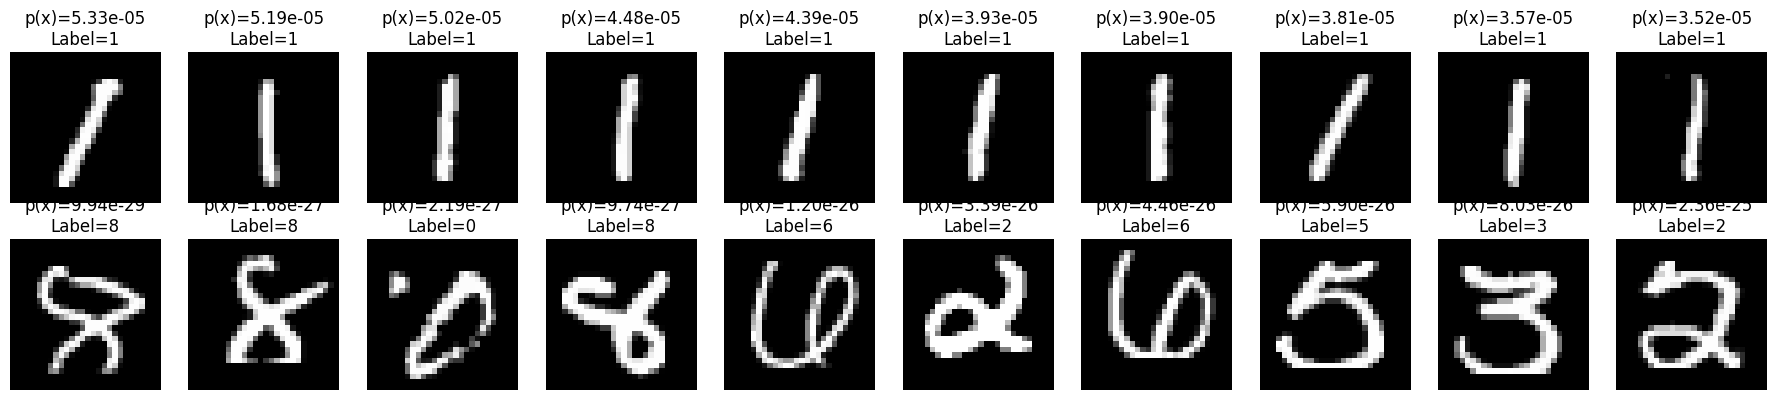

In [12]:
# Calculate p(x) for all test images and plot the 10 with highest and lowest probability
pxs = []
images = []
labels_px = []
vae.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        px = vae.estimate_px_monte_carlo(x, num_samples=100)
        pxs.append(px.cpu().numpy())
        images.append(x.cpu().numpy())
        labels_px.append(y.numpy())
pxs = np.concatenate(pxs, axis=0)
images = np.concatenate(images, axis=0)
labels_px = np.concatenate(labels_px, axis=0)

# Get indices of 10 highest and 10 lowest p(x)
highest_idx = np.argsort(pxs)[-10:][::-1]
lowest_idx = np.argsort(pxs)[:10]

# Plot images with highest p(x)
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for i, idx in enumerate(highest_idx):
    axes[0, i].imshow(images[idx].reshape(28, 28), cmap="gray")
    axes[0, i].set_title(f"p(x)={pxs[idx]:.2e}\nLabel={labels_px[idx]}")
    axes[0, i].axis("off")
for i, idx in enumerate(lowest_idx):
    axes[1, i].imshow(images[idx].reshape(28, 28), cmap="gray")
    axes[1, i].set_title(f"p(x)={pxs[idx]:.2e}\nLabel={labels_px[idx]}")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Highest p(x)")
axes[1, 0].set_ylabel("Lowest p(x)")
plt.tight_layout()
plt.show()

Is is remarkable how the images with the highest probabilities are all ones, so the model has learned very well to represent this digit. On the other hand, the images with the lowest probabilities digits with defects, for example, a truncated 8, a 0 with a fragment from another digit, and digits from very bad handwriting in general.

4. Train a VAE with a two-dimensional latent space $z \in \mathbb{R}^2$ on MNIST.
- Draw a scatter plot of the latent representations of the test images. Specify wether you use the mean $\mu_\phi(x)$ or samples $z \sim q_\phi(z|x)$. Color each point according to the digit it represents.
- Analyse: how separable do the digits appear in this low-dimensional latent space.
- Explain how the regularization term (KL) in the ELBO affects the organization of the latent space.
- Why does the latent representation of different digits tend to overlap, instead of forming separate clusters as in a classical autoencoder?
- Is there any degree of semantic structure (e.g., digits with similar strokes located near each other) in the latent space?
- Relate your explanations to the fact that the distributions $q_\phi(z|x)$ are forced to approximate the prior $p(z)\sim \mathcal{N}(0,I)$.

**Solution:**

A scatter plot of the latent representations of the MNIST test images is shown below. We used the mean $\mu_\phi(x)$ of the encoder distribution $q_\phi(z|x)$ as the latent representation for each image. Each point is colored according to the digit it represents.

In [13]:
dim_z = 2 # Latent space dimension
vae_2 = VAE(dim_input, hidden_units, dim_z).to(device)
optimizer = optim.Adam(vae_2.parameters(), lr=1e-3)

In [14]:
# Training loop
#
for epoch in range(epochs):
    vae_2.train()
    train_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, log_var = vae_2(x)
        loss = vae_loss(x, x_recon, mu, log_var)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader.dataset):.4f}")


Epoch 1/200, Loss: 62.3533
Epoch 2/200, Loss: 47.1712
Epoch 3/200, Loss: 44.5429
Epoch 4/200, Loss: 43.4351
Epoch 5/200, Loss: 42.6887
Epoch 6/200, Loss: 42.1476
Epoch 7/200, Loss: 41.7072
Epoch 8/200, Loss: 41.3700
Epoch 9/200, Loss: 41.0842
Epoch 10/200, Loss: 40.8353
Epoch 11/200, Loss: 40.6257
Epoch 12/200, Loss: 40.4217
Epoch 13/200, Loss: 40.2786
Epoch 14/200, Loss: 40.0929
Epoch 15/200, Loss: 39.9671
Epoch 16/200, Loss: 39.8327
Epoch 17/200, Loss: 39.7093
Epoch 18/200, Loss: 39.5767
Epoch 19/200, Loss: 39.4805
Epoch 20/200, Loss: 39.4018
Epoch 21/200, Loss: 39.2910
Epoch 22/200, Loss: 39.1939
Epoch 23/200, Loss: 39.1217
Epoch 24/200, Loss: 39.0313
Epoch 25/200, Loss: 38.9597
Epoch 26/200, Loss: 38.8821
Epoch 27/200, Loss: 38.7939
Epoch 28/200, Loss: 38.7234
Epoch 29/200, Loss: 38.6622
Epoch 30/200, Loss: 38.6026
Epoch 31/200, Loss: 38.5076
Epoch 32/200, Loss: 38.4490
Epoch 33/200, Loss: 38.3966
Epoch 34/200, Loss: 38.3596
Epoch 35/200, Loss: 38.2949
Epoch 36/200, Loss: 38.2503
E

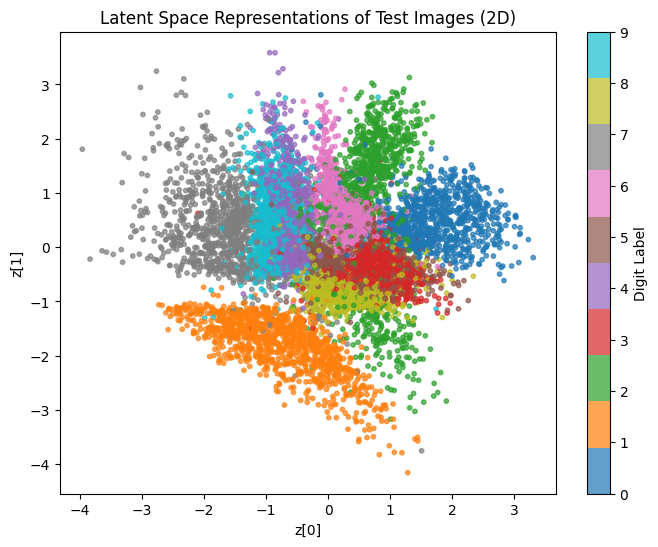

In [17]:
vae_2.eval()
latents = []
labels = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = vae_2.encoder(x)
        latents.append(mu.cpu().numpy())
        labels.append(y.numpy())
latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap="tab10", alpha=0.7, s=10)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label')
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("Latent Space Representations of Test Images (2D)")
plt.show()

There appears to be two classes of digits. While 7, 1 and 0 could be separated from the rest, digits like 9 and 4 are very close to each other, 2 appears to intersect with 6,5,8 and 3, and all five are very close to each other.

The KL divergence term in the ELBO acts as a regularizer that encourages the learned latent representations to be close to the prior distribution, in this case, a standard normal distribution. This has several effects on the organization of the latent space:
1. **Compactness**: The KL term encourages the latent representations to be more compact and centered around the origin. This prevents the latent space from becoming too spread out, which can help in learning more meaningful representations.
2. **Smoothness**: By penalizing deviations from the prior, the KL term promotes smooth transitions in the latent space, even between different classes. This can help in generating new samples that are coherent and similar to the training data.
3. **Spatial structure**: The KL term helps in maintaining a ball-like structure in the latent space, which disencourages the formation of isolated clusters. This can affect the separability of different classes, as seen in the scatter plot where some digits are closely packed together.

Using a $\beta$-VAE with $\beta < 1$ could potentially improve the separability of different digits in the latent space, as seen before in class. By reducing the weight of the KL divergence term, the model would be less constrained to keep the latent representations close to the prior distribution. This could allow for more distinct clusters to form for different digits, as the model would have more freedom to learn representations that are better suited for separating the classes. However, this could also lead to overfitting and less smoothness in the latent space, so it would be important to find a balance between reconstruction quality and latent space organization. It may be better to use conditional VAEs or other techniques specifically designed for disentangling factors of variation in the data.

There is a very clear structure, left to right we have the 7, then the 9 and 4, which are similar in the vertical, right side stroke, then we have the 6, 2 and 0, which transition from a diagonal stroke into a round shape. Coming down from 6, we have the 5, which is very similar to 6, just missing the closed loop at the bottom and the top horizontal stroke, as well as the 3, again very similar to 5, specially for some people's handwriting. Lower down we have the 8, which is similar to 3 and 5, but with the closed loop at the bottom and top, and we have some more 2's, which can be attributed to the fact that some people write 2's with a closed loop at the bottom, making them similar to 8's, while others write it with a flat stroke at the bottom. The one separable digit is the 1, while similar to 7, it has no horizontal strokes at all, making it very different from the rest.

5. Select two different digit images from the test set and obtain their latent representations $z_1$ and $z_2$.
- Linearly interpolate between $z_1$ and $z_2$ and reconstruct the images corresponding to the intermediate points.
- Analyse: how well does the model preserve semantic continuity across classes? Does the transition between digits appear smooth and coherent?

**Solution:**

The images below show the linear interpolation between a 1 and a 0, two very separate classes in the latent space as seen in the scatter plot above. As we can see, the transition is smooth and coherent, going from a 1 to an 8, then apparently to a 3, then what appears to be an 8 with a soft left side and center, and finally to a 0. This shows that the model is able to preserve semantic continuity across classes, even when interpolating between very different digits. The smooth transition indicates that the latent space learned by the VAE captures meaningful variations in the data, allowing for coherent transformations between different digit classes.

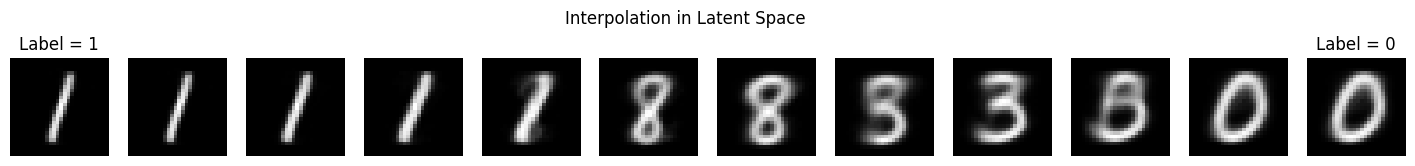

In [18]:
# Take the third and fourth image from the test set
vae_2.eval()
with torch.no_grad():
    for x, _ in test_loader:
        x_pair = x[2:4].to(device)  # third and fourth images
        mu, _ = vae_2.encoder(x_pair)
        break

# Linearly interpolate 10 points between the two encoded points
z1, z2 = mu[0], mu[1]
alphas = torch.linspace(0, 1, steps=10).unsqueeze(1).to(device)
z_interp = (1 - alphas) * z1 + alphas * z2

# Decode both encoded points and the interpolations
decoded_imgs = vae_2.decoder(z_interp)
decoded_orig_1 = vae_2.decoder(z1)
decoded_orig_2 = vae_2.decoder(z2)

# Plot original, encoded, and interpolated reconstructions
fig, axes = plt.subplots(1, 12, figsize=(18, 2))
# Original images
axes[0].imshow(decoded_orig_1.detach().cpu().view(28, 28), cmap="gray")
axes[0].set_title("Label = 1")
axes[0].axis("off")
axes[11].imshow(decoded_orig_2.detach().cpu().view(28, 28), cmap="gray")
axes[11].set_title("Label = 0")
axes[11].axis("off")
# Interpolated images
for i in range(10):
    axes[i+1].imshow(decoded_imgs[i].detach().cpu().view(28, 28), cmap="gray")
    axes[i+1].axis("off")
plt.suptitle("Interpolation in Latent Space")
plt.show()

### Excercise 3 (Extra credit)

Consider replacing the standard Gaussian decoder prior with a two-component mixture of Gaussians, each with diagonal covariance:
\begin{align*}
p(z) &= \pi_1 \mathcal{N}(z;\mu_1,\operatorname{diag}(\tau^2_1)) + \pi_2 \mathcal{N}(z;\mu_2,\operatorname{diag}(\tau^2_2))\\
\pi_1 + \pi_2 &= 1,\\
\pi_1, \pi_2 &\geq 0.
\end{align*}
Assume the encoder is also a diagonal Gaussian:
\begin{align*}
q_\phi(z|x) &= \mathcal{N}(z;\mu_\phi(x),\operatorname{diag}(\sigma^2_\phi(x))).
\end{align*}

1. Write explicitly the KL divergence term:
\begin{align*}
\operatorname{KL}(q_\phi(z|x) \| p(z)) &= \mathbb{E}_{q_\phi(z|x)} \left[ \log q_\phi(z|x) - \log p(z) \right].
\end{align*}
Identify which part of this expression prevents a closed-form evaluation.

**Solution:**

The KL divergence term can be expressed as:
\begin{align*}
\operatorname{KL}(q_\phi(z|x) \| p(z)) =& \mathbb{E}_{q_\phi(z|x)} \left[ \log q_\phi(z|x) - \log p(z) \right] \\
=& \mathbb{E}_{q_\phi(z|x)} \left[ \log \left( \exp \left( -\frac{1}{2} (z - \mu_\phi(x))^T \operatorname{diag}(\sigma^2_\phi(x))^{-1} (z - \mu_\phi(x)) \right) \right) - \frac{1}{2} \log \left( \left( 2 \pi \right)^d \det\left(\operatorname{diag}\left(\sigma^2_\phi(x) \right) \right) \right)\right]\\
&- \mathbb{E}_{q_\phi(z|x)} \left[ \log \left( \frac{\pi_1 \exp \left( -\frac{1}{2} (z - \mu_1)^T \operatorname{diag}(\tau^2_1)^{-1} (z - \mu_1) \right)}{\sqrt{(2 \pi)^d \det\left(\operatorname{diag}(\tau^2_1)\right)}} + \frac{\pi_2 \exp \left( -\frac{1}{2} (z - \mu_2)^T \operatorname{diag}(\tau^2_2)^{-1} (z - \mu_2) \right)}{\sqrt{(2 \pi)^d \det\left(\operatorname{diag}(\tau^2_2)\right)}} \right) \right]\\
=& -\frac{1}{2} \left( \mathbb{E}_{q_\phi(z|x)} \left[ (z - \mu_\phi(x))^T \operatorname{diag}(\sigma^2_\phi(x))^{-1} (z - \mu_\phi(x)) \right] + d \log(2\pi) + \log \det\left(\operatorname{diag}\left(\sigma^2_\phi(x) \right) \right) \right)\\
& - \mathbb{E}_{q_\phi(z|x)} \left[ \log \left( \frac{\pi_1 \exp \left( -\frac{1}{2} (z - \mu_1)^T \operatorname{diag}(\tau^2_1)^{-1} (z - \mu_1) \right)}{\sqrt{\det\left(\operatorname{diag}(\tau^2_1)\right)}} + \frac{\pi_2 \exp \left( -\frac{1}{2} (z - \mu_2)^T \operatorname{diag}(\tau^2_2)^{-1} (z - \mu_2) \right)}{\sqrt{ \det\left(\operatorname{diag}(\tau^2_2)\right)}} \right) \right] + \frac{d}{2}\log(2 \pi)\\
=& -\frac{1}{2} \left( \operatorname{tr} \left(\operatorname{diag}(\sigma^2_\phi(x))\operatorname{diag}(\sigma^2_\phi(x))^{-1}\right) + d \log(2\pi) + \log \det\left(\operatorname{diag}\left(\sigma^2_\phi(x) \right) \right) \right)\\
& - \mathbb{E}_{q_\phi(z|x)} \left[ \log \left( \frac{\pi_1 \exp \left( -\frac{1}{2} (z - \mu_1)^T \operatorname{diag}(\tau^2_1)^{-1} (z - \mu_1) \right)}{\sqrt{\det\left(\operatorname{diag}(\tau^2_1)\right)}} + \frac{\pi_2 \exp \left( -\frac{1}{2} (z - \mu_2)^T \operatorname{diag}(\tau^2_2)^{-1} (z - \mu_2) \right)}{\sqrt{ \det\left(\operatorname{diag}(\tau^2_2)\right)}} \right) \right] + \frac{d}{2}\log(2 \pi)\\
=& -\frac{1}{2} \left( d + d \log(2\pi) + \log \det\left(\operatorname{diag}\left(\sigma^2_\phi(x) \right) \right) \right)\\
& - \mathbb{E}_{q_\phi(z|x)} \left[ \log \left( \frac{\pi_1 \exp \left( -\frac{1}{2} (z - \mu_1)^T \operatorname{diag}(\tau^2_1)^{-1} (z - \mu_1) \right)}{\sqrt{\det\left(\operatorname{diag}(\tau^2_1)\right)}} + \frac{\pi_2 \exp \left( -\frac{1}{2} (z - \mu_2)^T \operatorname{diag}(\tau^2_2)^{-1} (z - \mu_2) \right)}{\sqrt{ \det\left(\operatorname{diag}(\tau^2_2)\right)}} \right) \right] + \frac{d}{2}\log(2 \pi)\\
=& -\frac{1}{2} \left( d + \log \det\left(\operatorname{diag}\left(\sigma^2_\phi(x) \right) \right) \right)\\
& - \mathbb{E}_{q_\phi(z|x)} \left[ \log \left( \frac{\pi_1 \exp \left( -\frac{1}{2} (z - \mu_1)^T \operatorname{diag}(\tau^2_1)^{-1} (z - \mu_1) \right)}{\sqrt{\det\left(\operatorname{diag}(\tau^2_1)\right)}} + \frac{\pi_2 \exp \left( -\frac{1}{2} (z - \mu_2)^T \operatorname{diag}(\tau^2_2)^{-1} (z - \mu_2) \right)}{\sqrt{ \det\left(\operatorname{diag}(\tau^2_2)\right)}} \right) \right]\\
\end{align*}
The part of this expression that prevents a closed-form evaluation is the expectation involving the logarithm of the sum of exponentials.

2. Implement a practical method (VAE with a Mixture-of-Gaussians prior) to approximate this KL term during training. In particular, use the estimator of the ELBO:
\begin{align*}
\hat{\mathcal{L}}(x) &= \frac{1}{K} \sum_{k=1}^K \left[ \log p_\phi (x\mid z^{(k)}) \right] + \log p(z^{(k)}) - \log q_\phi (z^{(k)} \mid x)
\end{align*}
Where $z^{(k)} \sim q_\phi(z|x)$.

In [19]:
# Hyperparameters
#
dim_input = 28 * 28 # Flattened MNIST image size
hidden_units = 128 # Hidden layer size
dim_z = 32 # Latent space dimension
batch_size = 256
epochs = 200
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
# Decoder p(x|z) as a mixture of two Gaussians per pixel
class MogDecoder(nn.Module):
    def __init__(self, z_dim, hidden_dim, output_dim):
        super(MogDecoder, self).__init__()
        self.fc1 = nn.Linear(z_dim, hidden_dim)
        # For each pixel: 2 means, 2 logvars, 1 mixing logit
        self.fc_means = nn.Linear(hidden_dim, output_dim * 2)
        self.fc_logvars = nn.Linear(hidden_dim, output_dim * 2)
        self.fc_logits = nn.Linear(hidden_dim, output_dim)
    def forward(self, z):
        h = F.relu(self.fc1(z))
        means = self.fc_means(h).view(-1, 2, self.fc_logits.out_features)      # (B, 2, D)
        logvars = self.fc_logvars(h).view(-1, 2, self.fc_logits.out_features)  # (B, 2, D)
        logits = self.fc_logits(h)                                             # (B, D)
        return means, logvars, logits

In [21]:
#
# Variational Autoencoder
#
class MogVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim):
        super(MogVAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, z_dim)
        self.decoder = MogDecoder(z_dim, hidden_dim, input_dim)
    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparameterize(mu, log_var)
        means, logvars, logits = self.decoder(z)
        return means, logvars, logits, mu, log_var
    def estimate_px_monte_carlo(self, x, num_samples=100):
        """
        Estimate p(x) for a batch of data x using the Monte Carlo estimator:
        (1/K) sum_k exp(log p_theta(x|z_k) + log p(z_k) - log q_phi(z_k|x))
        """
        self.eval()
        with torch.no_grad():
            mu, log_var = self.encoder(x)
            mu = mu.unsqueeze(1).expand(-1, num_samples, -1)
            log_var = log_var.unsqueeze(1).expand(-1, num_samples, -1)
            x_exp = x.unsqueeze(1).expand(-1, num_samples, -1)
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            z = mu + eps * std
            B, K, D = z.shape
            z_flat = z.reshape(B * K, D)
            means, logvars, logits = self.decoder(z_flat)
            means = means.view(B, K, 2, -1)
            logvars = logvars.view(B, K, 2, -1)
            logits = logits.view(B, K, -1)
            x_exp = x_exp.unsqueeze(2)  # (B, K, 1, D)
            # log p(x|z) for mixture of 2 Gaussians per pixel
            # log N(x|mu, sigma^2) for each component
            log_prob = -0.5 * (np.log(2 * np.pi) + logvars + ((x_exp - means) ** 2) / logvars.exp())
            log_prob = log_prob.sum(-1)  # sum over pixels, shape (B, K, 2)
            # log mixing coefficients (softmax over 2 components)
            log_pi = torch.log_softmax(logits.unsqueeze(2), dim=2)  # (B, K, 2, D) -> (B, K, 2, D)
            log_pi = log_pi.sum(-1)  # sum over pixels, shape (B, K, 2)
            # log-sum-exp over mixture components
            log_px_z = torch.logsumexp(log_pi + log_prob, dim=2)  # (B, K)
            # log p(z) for standard normal
            log_pz = -0.5 * (z ** 2 + np.log(2 * np.pi)).sum(dim=-1)
            # log q(z|x) for diagonal Gaussian
            log_qz_x = -0.5 * (((z - mu) ** 2) / (std ** 2) + 2 * torch.log(std) + np.log(2 * np.pi)).sum(dim=-1)
            log_weight = log_px_z + log_pz - log_qz_x
            px = torch.exp(torch.logsumexp(log_weight, dim=1) - np.log(num_samples))
        return px

In [22]:
# Loss function for mixture of two Gaussians decoder
def mog_vae_loss(x, mu, log_var, mog_vae, num_samples=1):
    # x: (B, D), mu/log_var: (B, z_dim)
    B, D = x.shape
    std = torch.exp(0.5 * log_var)
    elbos = []
    for _ in range(num_samples):
        eps = torch.randn_like(std)
        z = mu + eps * std  # (B, z_dim)
        means, logvars, logits = mog_vae.decoder(z)  # (B, 2, D), (B, 2, D), (B, D)
        x_exp = x.unsqueeze(1)  # (B, 1, D)
        # log N(x|mu, sigma^2) for each component
        log_prob = -0.5 * (np.log(2 * np.pi) + logvars + ((x_exp - means) ** 2) / logvars.exp())
        log_prob = log_prob.sum(-1)  # (B, 2)
        # log mixing coefficients (softmax over 2 components)
        log_pi = torch.log_softmax(logits, dim=1)  # (B, D)
        log_pi = log_pi.sum(-1, keepdim=True).expand(-1, 2)  # (B, 2)
        # log-sum-exp over mixture components
        log_px_z = torch.logsumexp(log_pi + log_prob, dim=1)  # (B,)
        # KL divergence between q(z|x) and p(z)
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)  # (B,)
        elbo = log_px_z - kl_loss / x.shape[0]
        elbos.append(elbo)
    elbos = torch.stack(elbos, dim=0)  # (num_samples, B)
    elbo_mean = elbos.mean(dim=0).mean()  # mean over samples and batch
    return -elbo_mean

In [23]:
mog_vae = MogVAE(dim_input, hidden_units, dim_z).to(device)
mog_optimizer = optim.Adam(mog_vae.parameters(), lr=1e-3)
K=5

In [24]:
# Training loop
#
for epoch in range(epochs):
    mog_vae.train()
    train_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        mog_optimizer.zero_grad()
        means, logvars, logits, mu, log_var = mog_vae(x)
        loss = mog_vae_loss(x, mu, log_var, mog_vae, num_samples=K)
        loss.backward()
        mog_optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader.dataset):.4f}")


Epoch 1/200, Loss: 19.0403
Epoch 2/200, Loss: 16.6913
Epoch 3/200, Loss: 16.8547
Epoch 4/200, Loss: 16.3220
Epoch 5/200, Loss: 16.1144
Epoch 6/200, Loss: 16.5236
Epoch 7/200, Loss: 16.4481
Epoch 8/200, Loss: 15.8093
Epoch 9/200, Loss: 15.5271
Epoch 10/200, Loss: 15.1392
Epoch 11/200, Loss: 14.6189
Epoch 12/200, Loss: 15.0776
Epoch 13/200, Loss: 14.9426
Epoch 14/200, Loss: 14.7581
Epoch 15/200, Loss: 14.3874
Epoch 16/200, Loss: 14.0674
Epoch 17/200, Loss: 14.3747
Epoch 18/200, Loss: 13.9540
Epoch 19/200, Loss: 14.2786
Epoch 20/200, Loss: 14.2772
Epoch 21/200, Loss: 13.7181
Epoch 22/200, Loss: 13.8243
Epoch 23/200, Loss: 14.0564
Epoch 24/200, Loss: 13.5766
Epoch 25/200, Loss: 13.4109
Epoch 26/200, Loss: 13.6941
Epoch 27/200, Loss: 13.4148
Epoch 28/200, Loss: 13.1273
Epoch 29/200, Loss: 13.4236
Epoch 30/200, Loss: 13.3016
Epoch 31/200, Loss: 12.7972
Epoch 32/200, Loss: 13.1678
Epoch 33/200, Loss: 12.8014
Epoch 34/200, Loss: 12.6926
Epoch 35/200, Loss: 12.7050
Epoch 36/200, Loss: 13.0669
E

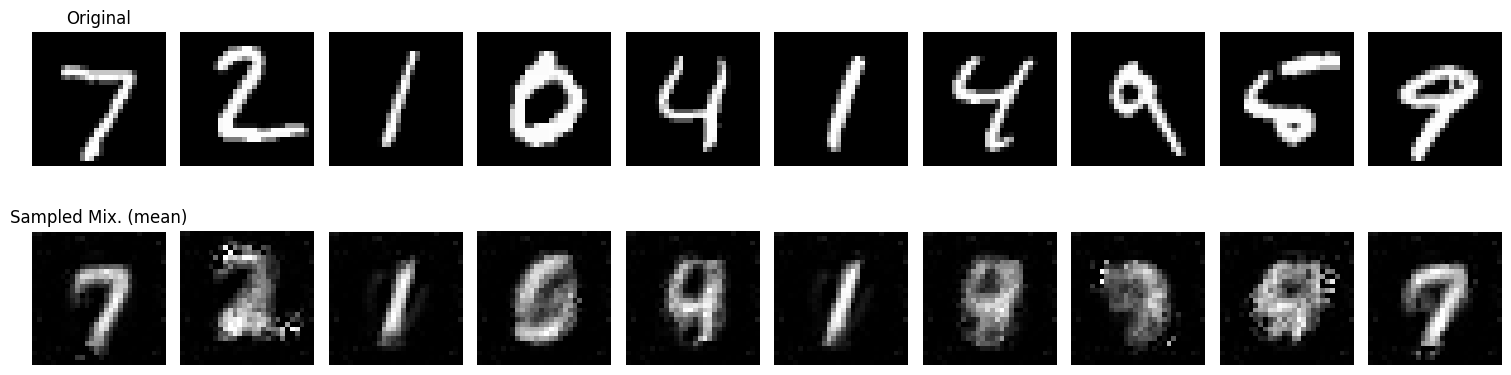

In [25]:
# Sample the first 10 images from the test dataset, with multiple samples for reconstruction
num_samples = 40  # Set your desired number of samples for reconstruction
mog_vae.eval()
with torch.no_grad():
    for x, _ in test_loader:
        x = x[:10].to(device)  # Take the first 10 images
        mu, log_var = mog_vae.encoder(x)
        std = torch.exp(0.5 * log_var)
        # Store reconstructions for each sample
        x_recon_samples = []
        for _ in range(num_samples):
            eps = torch.randn_like(std)
            z = mu + eps * std
            means, logvars, logits = mog_vae.decoder(z)
            # Compute softmax over logits to get mixture weights
            weights = torch.softmax(logits, dim=1)  # (B, D)
            # (A) Sample from the mixture for each pixel
            B, K, D = means.shape  # K=2
            means_np = means.cpu().numpy()
            logvars_np = logvars.cpu().numpy()
            weights_np = weights.cpu().numpy()
            x_np = x.cpu().numpy()
            x_recon_sampled = np.zeros((B, D))
            rng = np.random.default_rng()
            for b in range(B):
                for d in range(D):
                    comp = rng.choice(2, p=[weights_np[b, d], 1 - weights_np[b, d]])
                    mu_ = means_np[b, comp, d]
                    sigma_ = np.exp(0.5 * logvars_np[b, comp, d])
                    x_recon_sampled[b, d] = rng.normal(mu_, sigma_)
            x_recon_samples.append(x_recon_sampled)
        # Average over samples for each image
        x_recon_samples = np.stack(x_recon_samples, axis=0)  # (num_samples, B, D)
        x_recon_mean = x_recon_samples.mean(axis=0)  # (B, D)
        # (B) Use mean of most probable component per pixel (hard assignment) for the last sample
        comp_idx = (weights > 0.5).long()  # (B, D), 0 or 1
        comp_idx_exp = comp_idx.unsqueeze(1)  # (B, 1, D)
        break

# Plot original and reconstructed images (sampled from mixture)
fig, axes = plt.subplots(2, 10, figsize=(15, 4.5))
for i in range(10):
    # Original images
    axes[0, i].imshow(x_np[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
    # Sampled from mixture (mean over num_samples)
    axes[1, i].imshow(np.clip(x_recon_mean[i].reshape(28, 28), 0, 1), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Original")
axes[1, 0].set_title("Sampled Mix. (mean)")
plt.tight_layout()
plt.show()